In [2]:
import pandas as pd
import numpy as np

def data_preprocess(df):
    pixels = df["pixels"]
    y = df["emotion"]

    pixels = pixels.apply(lambda x: np.fromstring(x, sep=' '))
    pixels = np.stack(pixels.values)
    pixels = pixels.reshape(-1, 48, 48, 1)
    pixels = pixels.astype(np.float32) / 255.0

    return pixels, y

In [3]:
# # shows an image from the dataset
# import matplotlib.pyplot as plt
# df = pd.read_csv("data/train.csv")

# pixels, y = data_preprocess(df)

# img = pixels[44].reshape(48, 48)
    # plt.imshow(img, cmap='gray')
# plt.title(f"Emotion: {y[44]}")
# plt.axis('off')
# plt.show()

In [4]:
# training the cnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, Input
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from sklearn.model_selection import train_test_split

import datetime

df = pd.read_csv("data/train.csv")

pixels, y = data_preprocess(df)

X_train, X_test, y_train, y_test = train_test_split(pixels, y, test_size=0.2, random_state=42, stratify=y)

data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)


model = Sequential([
    Input(shape=(48,48,1)),
    data_augmentation,
    Conv2D(filters=32, kernel_size=(3,3), activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(7, activation="softmax")
])

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics= ["accuracy"],
)

history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test),callbacks=[tensorboard_callback, early_stop])

test_loss, test_accuracy = model.evaluate(X_test, y_test)
predictions = model.predict(X_test)
model.save("result/model/final_emotion_model.keras")


E0000 00:00:1785421068.765801  821340 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.2787 - loss: 1.8085 - val_accuracy: 0.3642 - val_loss: 1.6183
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3592 - loss: 1.6194 - val_accuracy: 0.3511 - val_loss: 1.6526
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.3972 - loss: 1.5367 - val_accuracy: 0.4460 - val_loss: 1.4475
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4316 - loss: 1.4679 - val_accuracy: 0.4805 - val_loss: 1.3524
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.4550 - loss: 1.4147 - val_accuracy: 0.5117 - val_loss: 1.2711
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4725 - loss: 1.3825 - val_accuracy: 0.5211 - val_loss: 1.2726
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.4912 - loss: 1.3360 - val_accuracy: 0.5275 - val_loss: 1.2259
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.5016 - loss: 1.3256 - 

FileNotFoundError: [Errno 2] No such file or directory: 'result/model/final_emotion_model.keras'

Training stopped after 25 epochs.


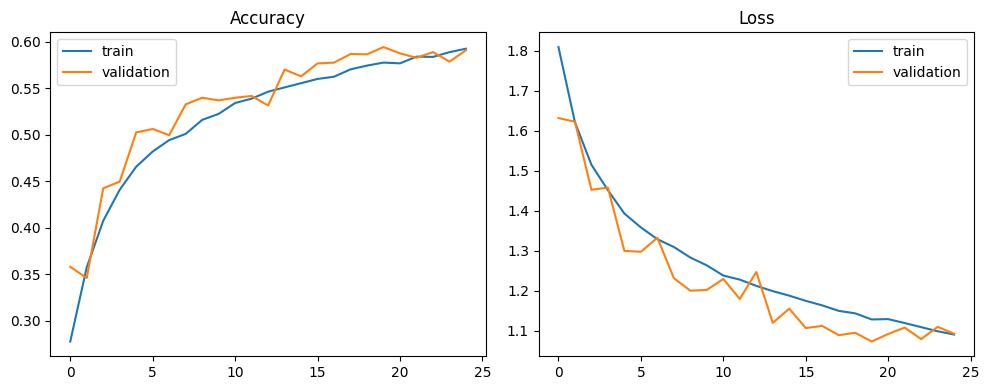

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/model/learning_curves.png")

print(f"Training stopped after {len(history.history['loss'])} epochs.")


plt.show()

In [ ]:
import pandas as pd
from tensorflow.keras.models import load_model

# Load model
model = load_model("final_emotion_model.keras")

# Load test data
df_test = pd.read_csv("data/test_with_emotions.csv")

# Preprocess
X_test, y_test = data_preprocess(df_test)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

model.summary()

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6087 - loss: 1.0605
Test Loss: 1.0605
Test Accuracy: 60.87%


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310,007 (5.00 MB)

 Trainable params: 436,455 (1.66 MB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 872,912 (3.33 MB)